In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
df = pd.read_csv(r"D:\Imarticus\Capstone project - 2\combined_reviews.csv.gz")   #gz for file is compressed and pandas can read it directly
df.head()

,rating,indication,date,duration,review_text,drug
0,5,Bipolar Disorder,"February 13, 2011",NaN,"""I know every medication works differently on ...",Abilify
1,10,Bipolar Disorder,"March 28, 2011",NaN,"""This medication worked so well for my bipolar...",Abilify
2,5,Bipolar Disorder,"December 13, 2015",NaN,"""I have taken Abilify for almost a year now on...",Abilify
3,1,Bipolar Disorder,"September 30, 2017",Taken for 1 to 6 months,"""This medication was the worst experience of m...",Abilify
4,2,Schizoaffective Disorder,"September 6, 2021",Taken for 5 to 10 years,"""This didn't help me and is very, very hard to...",Abilify


In [6]:
# Understand the dataset

print("Shape:", df.shape)

Shape: (44161, 6)


In [7]:
print("\nData types:\n", df.dtypes)


Data types:
 rating          int64
indication     object
date           object
duration       object
review_text    object
drug           object
dtype: object


In [8]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 rating             0
indication       951
date               0
duration       15100
review_text        0
drug               0
dtype: int64


In [10]:
# rating distribution 

print("Rating distribution (%):")
print((df['rating'].value_counts(normalize=True).sort_index() * 100).round(2))

Rating distribution (%):
rating
1     13.78
2      4.82
3      3.63
4      2.77
5      4.87
6      4.11
7      6.25
8     11.74
9     16.72
10    31.31
Name: proportion, dtype: float64


In [11]:
# drug counts
print("\nNumber of unique drugs:", df['drug'].nunique())
print(df['drug'].value_counts())


Number of unique drugs: 36
drug
Semaglutide      3840
Mounjaro         2880
Gabapentin       2621
Paroxetine       2537
Duloxetine       2505
Lexapro          2426
Tramadol         1913
Doxycycline      1658
Zolpidem         1633
Prozac           1269
Abilify          1224
Buprenorphine    1187
Oxycodone        1164
Trintellix       1160
Effexor XR       1034
Vyvanse           999
Trulicity         987
Lyrica            940
Xanax             935
Diazepam          915
Repatha           905
Prednisone        884
Wellbutrin        777
Seroquel          717
Diclofenac        714
Humira            706
Aimovig           674
Metformin         671
Dupixent          632
Vraylar           619
Rexulti           557
Adderall          522
Emgality          516
Sildenafil        512
Botox             511
Epclusa           417
Name: count, dtype: int64


In [12]:
# checking indication count

pd.set_option('display.max_rows', None)
print("Raw indication value_counts:")
print(df['indication'].value_counts())

Raw indication value_counts:
indication
Depression                                                              4750
Type 2 Diabetes                                                         4285
Anxiety                                                                 4038
Weight Loss                                                             2867
Pain                                                                    2041
Insomnia                                                                1819
Major Depressive Disorder                                               1769
Chronic Pain                                                            1733
Bipolar Disorder                                                        1448
Migraine Prevention                                                     1299
ADHD                                                                    1291
Generalized Anxiety Disorder                                            1150
Fibromyalgia                        

In [13]:
# Data cleaning, dropping date and duration

df = df.drop(columns=['date', 'duration'])

drug_names = set(df['drug'].unique())
mask = df['indication'].isin(drug_names)
print("Rows corrected:", mask.sum())
df.loc[mask, 'indication'] = None

Rows corrected: 153


In [14]:
# standardize the near-duplicate indication labels

indication_merge_map = {
    "Major Depressive Disorder": "Depression",
    "Persistent Depressive Disorder": "Depression",
    "Postpartum Depression": "Depression",
    "Generalized Anxiety Disorder": "Anxiety",
    "Anxiety and Stress": "Anxiety",
    "Chronic Pain": "Pain",
    "Crohn's Disease, Active": "Crohn's Disease",
    "Crohn's Disease, Maintenance": "Crohn's Disease",
    "High Cholesterol - Familial Heterozygous": "High Cholesterol",
    "High Cholesterol - Familial Homozygous": "High Cholesterol",
    "Asthma, Maintenance": "Asthma",
    "Ulcerative Colitis, Active": "Ulcerative Colitis",
    "Lyme Disease, Neurologic": "Lyme Disease",
    "Lyme Disease, Arthritis": "Lyme Disease",
    "Opiate Dependence - Maintenance": "Opioid Use Disorder",
    "Opiate Withdrawal": "Opioid Use Disorder",
    "Plaque Psoriasis": "Psoriasis",
}

df['indication'] = df['indication'].replace(indication_merge_map)

print("Unique indication values now:", df['indication'].nunique())
print(df['indication'].value_counts().head(25))

Unique indication values now: 197
indication
Depression                                                              6561
Anxiety                                                                 5906
Type 2 Diabetes                                                         4285
Pain                                                                    3774
Weight Loss                                                             2867
Insomnia                                                                1819
Bipolar Disorder                                                        1448
Migraine Prevention                                                     1299
ADHD                                                                    1291
Fibromyalgia                                                            1095
Acne                                                                     780
High Cholesterol                                                         763
Panic Disorder                 

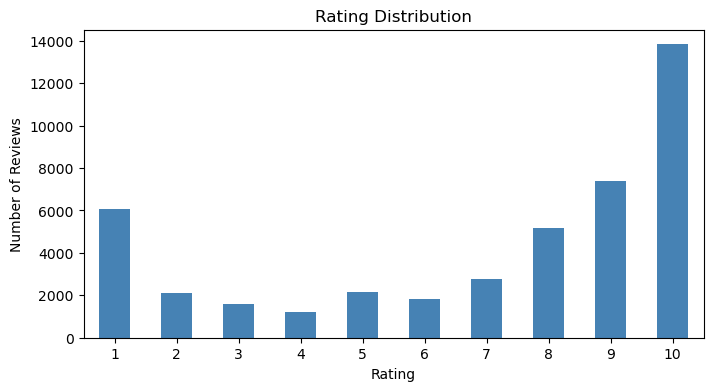

In [17]:
# Rating distribution
plt.figure(figsize=(8,4))
df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Rating Distribution')
plt.xlabel('Rating'); plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

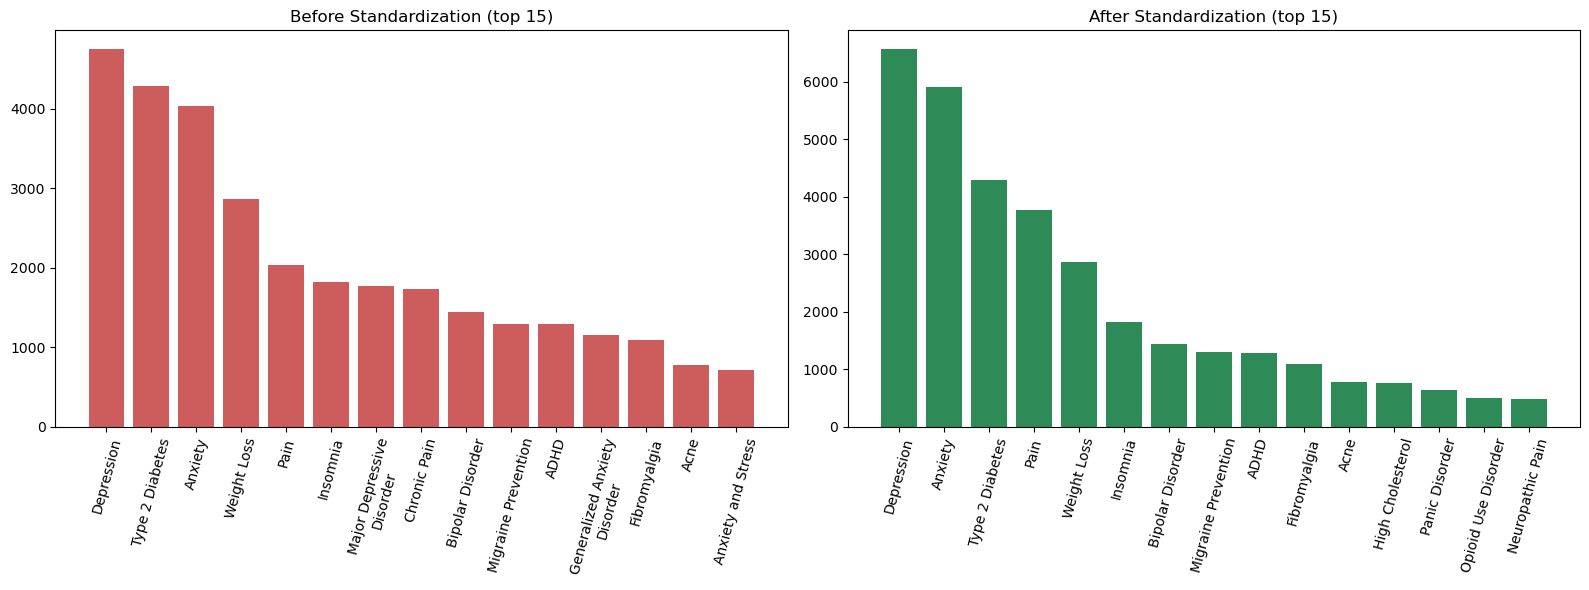

In [16]:
# Indication distribution: before vs after standardization (top 15 each)
before_counts = {
    'Depression': 4750, 'Type 2 Diabetes': 4285, 'Anxiety': 4038, 'Weight Loss': 2867,
    'Pain': 2041, 'Insomnia': 1819, 'Major Depressive\nDisorder': 1769, 'Chronic Pain': 1733,
    'Bipolar Disorder': 1448, 'Migraine Prevention': 1299, 'ADHD': 1291,
    'Generalized Anxiety\nDisorder': 1150, 'Fibromyalgia': 1095, 'Acne': 780,
    'Anxiety and Stress': 718,
}
after_counts = df['indication'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].bar(before_counts.keys(), before_counts.values(), color='indianred')
axes[0].set_title('Before Standardization (top 15)')
axes[0].tick_params(axis='x', rotation=75)

axes[1].bar(after_counts.index, after_counts.values, color='seagreen')
axes[1].set_title('After Standardization (top 15)')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

Major Depressive Disorder, Chronic Pain, Generalized Anxiety Disorder, and Anxiety and Stress all vanish from the "after" side because they merged into their parent categories, and High Cholesterol / Opioid Use Disorder now surface into the top 15 since they got consolidated too.

In [18]:
# cleaning the review text itself

stop_words = set(stopwords.words('english'))   # common filler words (the, is, and...) that carry little meaning
lemmatizer = WordNetLemmatizer()                # reduces words to their base form (running -> run)

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)                # remove leftover HTML tags <b> from the scraped page
    text = re.sub(r'\d+', ' <NUM> ', text)             # replace numbers with a placeholder, so "50mg" and "10mg" aren't treated as different words
    text = re.sub(r'[^A-Za-z\s<>]', ' ', text)          # remove punctuation and special characters, keep only letters/spaces/the <NUM> tag
    text = text.lower()                                 
    text = ' '.join(text.split())                       # collapse multiple spaces left behind by the steps above into one
    words = text.split()                                # filtering stopwords
    words = [w for w in words if w not in stop_words]  # drop stopwords — they add length without adding meaning
    words = [lemmatizer.lemmatize(w) for w in words]    # normalize each word to its base form
    return ' '.join(words)

df['clean_text'] = df['review_text'].apply(clean_text)  # apply the full cleaning pipeline to every review
df[['review_text', 'clean_text']].head()

,review_text,clean_text
0,"""I know every medication works differently on ...",know every medication work differently person ...
1,"""This medication worked so well for my bipolar...",medication worked well bipolar side effect exc...
2,"""I have taken Abilify for almost a year now on...",taken abilify almost year make gain weight lam...
3,"""This medication was the worst experience of m...",medication worst experience life lot rubbish e...
4,"""This didn't help me and is very, very hard to...",help hard discontinue made psychotic tremor re...


In [19]:
# Train-Test Split

top_20 = df['indication'].value_counts().head(20).index
df['indication_bucketed'] = df['indication'].apply(lambda x: x if x in top_20 else "Other")
print(df['indication_bucketed'].value_counts())

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['indication_bucketed']
)
print("\nTrain size:", len(train_df), "Test size:", len(test_df))

indication_bucketed
Other                            8583
Depression                       6561
Anxiety                          5906
Type 2 Diabetes                  4285
Pain                             3774
Weight Loss                      2867
Insomnia                         1819
Bipolar Disorder                 1448
Migraine Prevention              1299
ADHD                             1291
Fibromyalgia                     1095
Acne                              780
High Cholesterol                  763
Panic Disorder                    648
Opioid Use Disorder               495
Neuropathic Pain                  479
Cardiovascular Risk Reduction     449
Back Pain                         448
Erectile Dysfunction              447
Hepatitis C                       416
Eczema                            308
Name: count, dtype: int64

Train size: 35328 Test size: 8833


In [20]:
# Sequence Preparation re-verify the real numbers on this split

temp_tokenizer = Tokenizer()
temp_tokenizer.fit_on_texts(train_df['clean_text'])
print("Total unique words:", len(temp_tokenizer.word_index))

lengths = train_df['clean_text'].str.split().str.len()
print(lengths.describe())
print("90th pct:", lengths.quantile(0.90))
print("95th pct:", lengths.quantile(0.95))
print("99th pct:", lengths.quantile(0.99))

# num_words=20000 and maxlen=100 are the right calls

Total unique words: 18892
count    35328.000000
mean        45.783118
std         26.310209
min          1.000000
25%         24.000000
50%         43.000000
75%         66.000000
max        543.000000
Name: clean_text, dtype: float64
90th pct: 83.0
95th pct: 92.0
99th pct: 104.0


In [21]:
tokenizer = Tokenizer(num_words=20000)          # keep the 20,000 most frequent words (covers our real ~18,900-word vocabulary)
tokenizer.fit_on_texts(train_df['clean_text'])  # learn the vocabulary from training data only, never from test data

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])  # convert each review's words into integer IDs
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])    # same conversion, using the vocabulary learned from train only

maxlen = 100                                          # cap every review at 100 words (covers ~95%+ of reviews, per the percentile check)
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)  # pad short reviews / truncate long ones so every sequence is the same length
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

print(X_train_pad.shape, X_test_pad.shape)   # sanity check: should be (35328, 100) and (8833, 100)

(35328, 100) (8833, 100)


In [22]:
# Rating target — just the raw numeric values, no encoding needed (regression)
y_train_rating = train_df['rating'].values
y_test_rating = test_df['rating'].values

# Indication target — convert the 21 text class labels into integers for the model
label_encoder = LabelEncoder()
y_train_indication = label_encoder.fit_transform(train_df['indication_bucketed'])  # learn the label mapping from train only
y_test_indication = label_encoder.transform(test_df['indication_bucketed'])        # apply the same mapping to test

print(label_encoder.classes_)   # confirm all 21 classes are present

['ADHD' 'Acne' 'Anxiety' 'Back Pain' 'Bipolar Disorder'
 'Cardiovascular Risk Reduction' 'Depression' 'Eczema'
 'Erectile Dysfunction' 'Fibromyalgia' 'Hepatitis C' 'High Cholesterol'
 'Insomnia' 'Migraine Prevention' 'Neuropathic Pain' 'Opioid Use Disorder'
 'Other' 'Pain' 'Panic Disorder' 'Type 2 Diabetes' 'Weight Loss']


Handle Imbalanced Data (indication model only — rating is a regression target, not a class-imbalance problem)

In [23]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train_indication),
    y=y_train_indication
)                                            # gives higher weight to rare classes (like Eczema, Erectile Dysfunction) during training
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.6285437698796847), 1: np.float64(2.695970695970696), 2: np.float64(0.3560393046107332), 3: np.float64(4.699122106943336), 4: np.float64(1.452751048605971), 5: np.float64(4.686032630322324), 6: np.float64(0.32049642108700976), 7: np.float64(6.810873337189126), 8: np.float64(4.699122106943336), 9: np.float64(1.9204174820613176), 10: np.float64(5.0519090519090515), 11: np.float64(2.7578454332552695), 12: np.float64(1.1562101129111437), 13: np.float64(1.6191392822769146), 14: np.float64(4.392390898918314), 15: np.float64(4.2481962481962485), 16: np.float64(0.24501685323124298), 17: np.float64(0.5572327639237212), 18: np.float64(3.2476558190843905), 19: np.float64(0.49074845807634604), 20: np.float64(0.733341636567443)}


In [24]:
# Build Baseline Architecture

# Model 1 — Rating (regression, predicts 1-10)
model_rating = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=128, mask_zero=True),  # turns word IDs into learned 128-dim vectors; mask_zero ignores padding
    Bidirectional(LSTM(64)),                                      # reads the review forward and backward
    Dropout(0.3),                                                 # randomly drops connections during training to reduce overfitting
    Dense(32, activation='relu'),
    Dense(1)                                                      # single number output, no activation -> raw regression value
])
model_rating.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model_rating.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,662,977 (10.16 MB)

 Trainable params: 2,662,977 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Model 2 — Indication (classification, 21 classes)
model_indication = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=128, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(21, activation='softmax')   # 21 probabilities (one per class), summing to 1
])

model_indication.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_indication.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 100, 128)            │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,663,637 (10.16 MB)

 Trainable params: 2,663,637 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#Training the model

early_stop_rating = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rating = model_rating.fit(
    X_train_pad, y_train_rating,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_rating]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 223s 459ms/step - loss: 9.8353 - mae: 2.4720 - val_loss: 5.6993 - val_mae: 1.8004
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 312s 571ms/step - loss: 5.0541 - mae: 1.7050 - val_loss: 5.3163 - val_mae: 1.7181
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 247s 538ms/step - loss: 3.9687 - mae: 1.4833 - val_loss: 5.3596 - val_mae: 1.7014
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 224s 452ms/step - loss: 3.1440 - mae: 1.3002 - val_loss: 5.4781 - val_mae: 1.6917
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 206s 462ms/step - loss: 2.5590 - mae: 1.1672 - val_loss: 5.7022 - val_mae: 1.6823


In [29]:
# final check on test data

test_loss, test_mae = model_rating.evaluate(X_test_pad, y_test_rating)  # loss = MSE, mae = mean absolute error
y_pred_rating = model_rating.predict(X_test_pad)
r2 = r2_score(y_test_rating, y_pred_rating)

print("Test MAE:", test_mae)
print("Test R²:", r2)

277/277 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - loss: 5.4200 - mae: 1.7312
277/277 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step
Test MAE: 1.7311744689941406
Test R²: 0.49598151445388794


In [30]:
# train Model 2 (indication) on the newly standardized classes

early_stop_indication = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_indication = model_indication.fit(
    X_train_pad, y_train_indication,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,   # apply the balanced weights from Step 8
    callbacks=[early_stop_indication]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 245s 512ms/step - accuracy: 0.2021 - loss: 2.2157 - val_accuracy: 0.3929 - val_loss: 1.7681
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 278s 548ms/step - accuracy: 0.4433 - loss: 1.2163 - val_accuracy: 0.4636 - val_loss: 1.6115
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 261s 547ms/step - accuracy: 0.5400 - loss: 0.8876 - val_accuracy: 0.5412 - val_loss: 1.3847
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 285s 644ms/step - accuracy: 0.6183 - loss: 0.6670 - val_accuracy: 0.5559 - val_loss: 1.3379
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 267s 603ms/step - accuracy: 0.6740 - loss: 0.5458 - val_accuracy: 0.5948 - val_loss: 1.2764
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 251s 568ms/step - accuracy: 0.7169 - loss: 0.4577 - val_accuracy: 0.6047 - val_loss: 1.3518
Epoch 7/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 235s 532ms/step - accuracy: 0.7534 - loss: 0.3935 - val_accuracy: 0.6243 - val_loss: 1.3045
Epoch 8/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 219s 496ms/step - accuracy: 0.7910 -

In [31]:
# final check on test data

y_pred_indication = model_indication.predict(X_test_pad)
y_pred_indication_classes = y_pred_indication.argmax(axis=1)   # convert 21 probabilities into the single predicted class

test_accuracy = (y_pred_indication_classes == y_test_indication).mean()
print("Test accuracy:", test_accuracy)

print(classification_report(y_test_indication, y_pred_indication_classes, target_names=label_encoder.classes_))

277/277 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
Test accuracy: 0.5916449677346315
                               precision    recall  f1-score   support

                         ADHD       0.77      0.84      0.80       258
                         Acne       0.76      0.92      0.83       156
                      Anxiety       0.61      0.67      0.64      1181
                    Back Pain       0.14      0.49      0.22        90
             Bipolar Disorder       0.50      0.66      0.57       290
Cardiovascular Risk Reduction       0.12      0.37      0.18        90
                   Depression       0.69      0.63      0.66      1312
                       Eczema       0.49      0.75      0.60        61
         Erectile Dysfunction       0.55      0.83      0.66        89
                 Fibromyalgia       0.28      0.74      0.41       219
                  Hepatitis C       0.72      0.86      0.78        83
             High Cholesterol       0.76      0.71      0.73       153


In [36]:
# Visualize for both models

def plot_curves(history, metric):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.legend(['Train', 'Validation'])

    plt.subplot(1,2,2)
    plt.plot(history.history[metric])
    plt.plot(history.history['val_' + metric])
    plt.title('Model ' + metric)
    plt.legend(['Train', 'Validation'])

    plt.show()

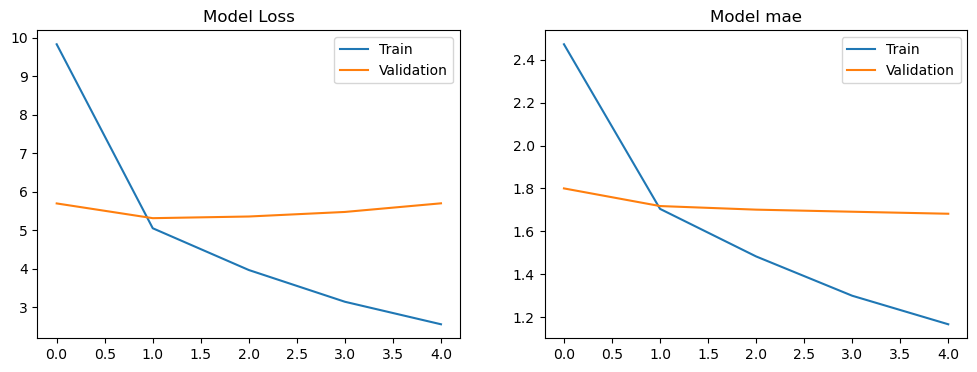

In [37]:
# For rating plot
plot_curves(history_rating, metric='mae')

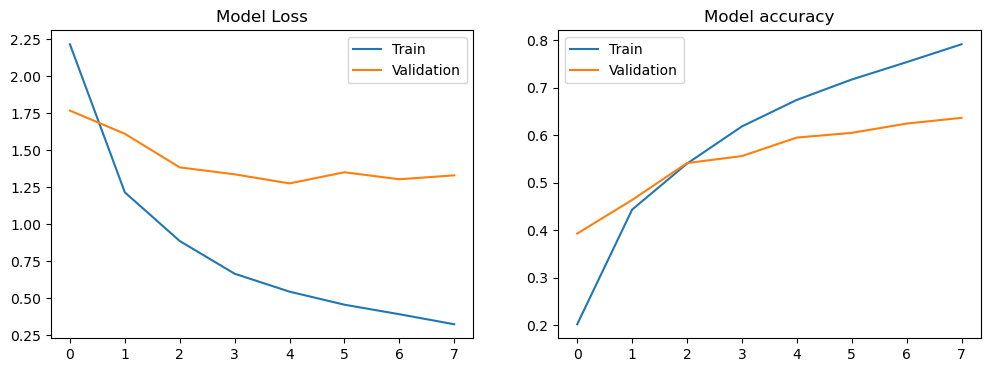

In [38]:
# for indication plot

plot_curves(history_indication, metric='accuracy')

In [39]:
# Interpretability check which words affect the rating" tool

def predict_rating(text):
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=maxlen)
    return model_rating.predict(pad, verbose=0)[0][0]

sample_review = test_df['clean_text'].iloc[0]
words = sample_review.split()
original_pred = predict_rating(sample_review)
print("Review:", sample_review)
print("Predicted rating:", original_pred)

Review: eighth month medication titrated slowly standard <num> <num> currently <num> <num> manageable side effect including nausea occasionally constipation keep bay hydration psyllium miralax sour stomach time papaya enzyme deal needed overall medicine godsend food noise inflammation vastly reduced blood work number improved magic eat clean track food macro hydration exercise lost <num> body weight aiming least <num> seems possible since even one year point
Predicted rating: 8.747569


In [41]:
# word-by-word test

impacts = []
for i in range(len(words)):
    words_removed = words[:i] + words[i+1:]
    text_removed = ' '.join(words_removed)
    new_pred = predict_rating(text_removed)
    shift = original_pred - new_pred   # corrected: positive = word was pushing rating up, negative = word was pulling it down
    impacts.append((words[i], shift))

impacts.sort(key=lambda x: x[1])

print("Words pulling the rating DOWN (removing them raised the prediction):")
for word, shift in impacts[:5]:
    print(f"{word}: {shift:.3f}")

print("\nWords pushing the rating UP (removing them lowered the prediction):")
for word, shift in impacts[-5:]:
    print(f"{word}: {shift:.3f}")

Words pulling the rating DOWN (removing them raised the prediction):
point: -0.136
medication: -0.104
even: -0.074
month: -0.069
titrated: -0.060

Words pushing the rating UP (removing them lowered the prediction):
magic: 0.022
occasionally: 0.030
manageable: 0.031
godsend: 0.032
year: 0.167


In [42]:
# building your baseline models (the simple, non-deep-learning comparison)

# imports and the TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression

tfidf = TfidfVectorizer(max_features=20000)          # same vocabulary budget as the LSTM tokenizer, for a fair comparison
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])  # learn vocabulary from training data only
X_test_tfidf = tfidf.transform(test_df['clean_text'])

print(X_train_tfidf.shape, X_test_tfidf.shape)

(35328, 18870) (8833, 18870)


In [43]:
baseline_rating = LinearRegression()
baseline_rating.fit(X_train_tfidf, y_train_rating)

y_pred_rating_baseline = baseline_rating.predict(X_test_tfidf)

baseline_mae = mean_absolute_error(y_test_rating, y_pred_rating_baseline)
baseline_r2 = r2_score(y_test_rating, y_pred_rating_baseline)

print("Baseline Test MAE:", baseline_mae)
print("Baseline Test R²:", baseline_r2)

Baseline Test MAE: 2.5198009470072726
Baseline Test R²: -0.16301072946037887


plain Linear Regression on raw TF-IDF with ~18,870 features and only 35,328 training rows tends to badly overfit — each word gets its own independent coefficient with no way to share information between related words or understand context, so it essentially memorizes noise in the training set and fails to generalize.

In [44]:
Using Regularization technique Ridge

from sklearn.linear_model import Ridge

baseline_rating_ridge = Ridge(alpha=1.0)
baseline_rating_ridge.fit(X_train_tfidf, y_train_rating)

y_pred_ridge = baseline_rating_ridge.predict(X_test_tfidf)

print("Ridge Baseline Test MAE:", mean_absolute_error(y_test_rating, y_pred_ridge))
print("Ridge Baseline Test R²:", r2_score(y_test_rating, y_pred_ridge))

Ridge Baseline Test MAE: 1.9113318311419893
Ridge Baseline Test R²: 0.4695277994428997


a properly regularized simple model gets surprisingly close on variance explained, but the LSTM still produces measurably more accurate individual predictions. That's a much more defensible and nuanced claim than "deep learning wins dramatically" — and it's more credible in an interview, because it shows you didn't just cherry-pick the baseline that made your model look best (which the plain Linear Regression result would have done, dishonestly).

In [45]:
# indication model — TF-IDF + Logistic Regression, same train/test split, same class_weight='balanced' approach as LSTM used

from sklearn.linear_model import LogisticRegression

# Logistic Regression baseline for indication classification.
# max_iter increased because TF-IDF has 18,870 features - default 100 iterations
# often isn't enough for the solver to converge on data this wide.
# class_weight='balanced' mirrors what we did for model_indication, so it's a fair comparison.
baseline_indication = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_indication.fit(X_train_tfidf, y_train_indication)

y_pred_indication_baseline = baseline_indication.predict(X_test_tfidf)

baseline_accuracy = (y_pred_indication_baseline == y_test_indication).mean()
print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Accuracy: 0.6758745613042002


the honest final story for the indication task is now "a properly-built LSTM did not outperform a simple regularized baseline — and that itself is a meaningful, explainable finding, not a failure." That's actually a stronger thing to say in an interview than "deep learning won everything," because it shows you understand when deep learning helps and when it doesn't, instead of assuming it's always better.

In [46]:
from sklearn.metrics import classification_report

# Full per-class breakdown for the baseline, using the same label_encoder
# classes as the LSTM so the two reports line up exactly.
print(classification_report(y_test_indication, y_pred_indication_baseline, target_names=label_encoder.classes_))

                               precision    recall  f1-score   support

                         ADHD       0.77      0.90      0.83       258
                         Acne       0.89      0.95      0.92       156
                      Anxiety       0.71      0.62      0.66      1181
                    Back Pain       0.19      0.49      0.28        90
             Bipolar Disorder       0.48      0.68      0.56       290
Cardiovascular Risk Reduction       0.19      0.31      0.24        90
                   Depression       0.74      0.68      0.71      1312
                       Eczema       0.51      0.89      0.65        61
         Erectile Dysfunction       0.63      0.93      0.75        89
                 Fibromyalgia       0.59      0.68      0.63       219
                  Hepatitis C       0.92      0.87      0.89        83
             High Cholesterol       0.74      0.83      0.78       153
                     Insomnia       0.78      0.90      0.84       364
     

for indication classification specifically, the simple, well-regularized linear baseline beat the LSTM by a clear, consistent margin across every metric. The honest explanation is that this task is closer to keyword classification than sequence understanding, so word-order modeling (the LSTM's main advantage) doesn't pay off here, while the LSTM's need to learn embeddings from scratch on a comparatively small dataset works against it. This is a legitimate, well-supported finding — not a failure to report quietly.

With both baselines done, the full modeling story is now final:

Rating: LSTM wins (MAE 1.73 vs Ridge 1.91) — deep learning genuinely helps here.
Indication: Baseline wins (67.6% vs LSTM 59.2%) — deep learning does not help here, and you can explain exactly why.

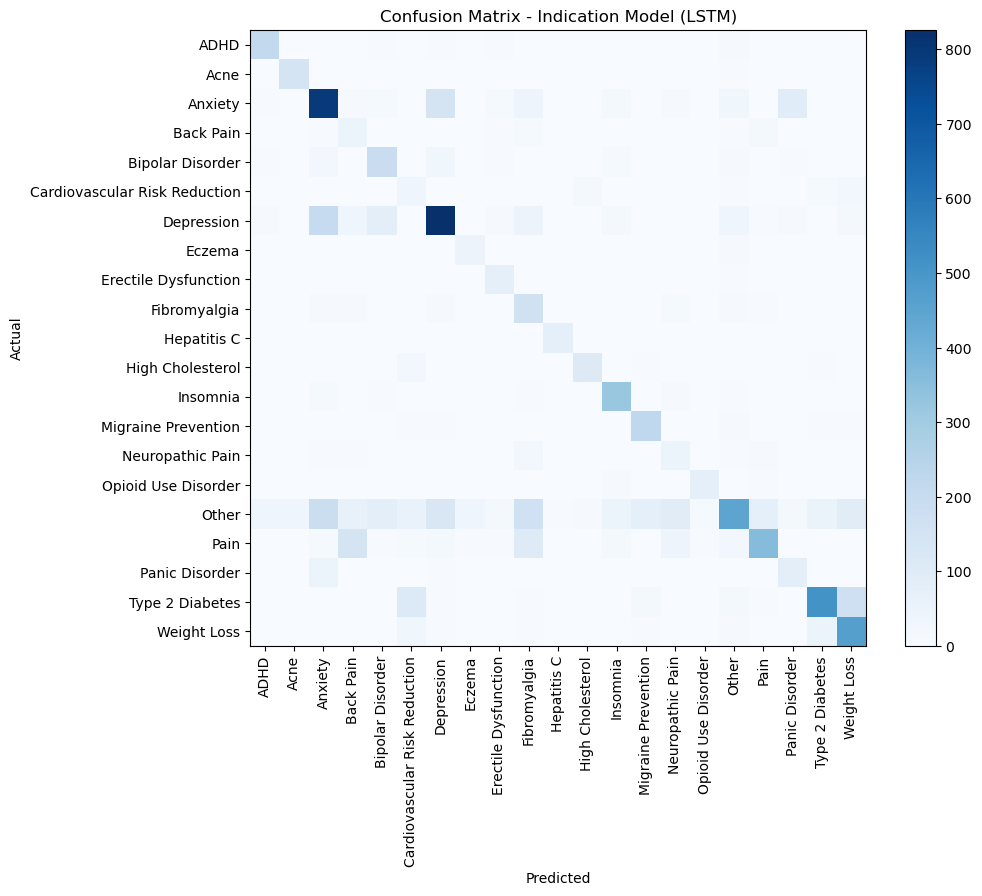

In [47]:
from sklearn.metrics import confusion_matrix

# Get the LSTM's actual predicted class for every test review.
# model_indication.predict() gives a probability for each of the 21 classes,
# so we take the class with the highest probability using argmax.
y_pred_indication = model_indication.predict(X_test_pad, verbose=0).argmax(axis=1)

# Build the confusion matrix: rows = true label, columns = predicted label.
# cm[i][j] = number of reviews whose true class was i but got predicted as j.
cm = confusion_matrix(y_test_indication, y_pred_indication)

# Plot it as a heatmap so misclassification patterns are easy to spot visually.
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=90)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Indication Model (LSTM)')
plt.show()

here's the actual confusion matrix, and it confirms the overlap is concentrated in clinically related condition pairs, not scattered randomly.

In [48]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.4 MB 4.4 MB/s eta 0:00:06
   --- ------------------------------------ 2.4/24.4 MB 4.8 MB/s eta 0:00:05
   ------ --------------------------------- 3.7/24.4 MB 5.2 MB/s eta 0:00:04
   ------- -------------------------------- 4.5/24.4 MB 4.8 MB/s eta 0:00:05
   --------- ------------------------------ 5.8/24.4 MB 5.1 MB/s eta 0:00:04
   ----------- ---------------------------- 7.1/24.4 MB 5.2 MB/s eta 0:00:04
   ------------- -------------------------- 8.4/24.4 MB 5.3 MB/s eta 0:00:03
   --------------- ------------------------ 9.7/24.4 MB 5.5 MB/s eta 0:00:03
   ------------------ --------------------- 11.0/24.4 MB 5.6 MB/s eta 0:00:03
   -------------------- ------------------- 12.3/24.4 MB 5.7 MB/s eta 0:00:03
   ---------------------- ----------------- 13.6/24.4 MB 5.7 MB/s eta 0:00:02
   -------

In [49]:
# transfer learning

import gensim.downloader as api

# Load pretrained GloVe word vectors (100-dimensional, trained on Wikipedia + Gigaword,
# a huge general-English text corpus). This downloads automatically the first time
# (~128MB) and is cached locally after that, so it'll be instant on future runs.
glove_vectors = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [50]:
import numpy as np

# Build an embedding matrix: row i = the GloVe vector for the word that
# our tokenizer assigned index i to. This matrix will be handed to Keras
# as the Embedding layer's starting weights, instead of random initialization.
embedding_dim = 100
embedding_matrix = np.zeros((20000, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= 20000:
        continue
    if word in glove_vectors:
        embedding_matrix[i] = glove_vectors[word]

# Check GloVe's actual coverage of your vocabulary - some words (medical slang,
# misspellings, drug brand names) won't have a pretrained vector and stay all zeros,
# meaning the model will have to learn those from scratch during training, same as before.
found = np.sum(np.any(embedding_matrix != 0, axis=1))
print(f"Words matched to GloVe vectors: {found} out of 20000")

Words matched to GloVe vectors: 17044 out of 20000


In [51]:
# model using this matrix as the Embedding layer's starting point

# Same architecture as model_indication, but the Embedding layer now starts from
# pretrained GloVe vectors instead of random weights.
# trainable=True means the model is still allowed to adjust these vectors during
# training (fine-tuning) - so it keeps GloVe's general English knowledge as a
# starting point, but can shift word meanings toward drug-review-specific usage.
model_indication_v2 = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=embedding_dim, weights=[embedding_matrix], trainable=True, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(21, activation='softmax')
])
model_indication_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_indication_v2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,089,301 (7.97 MB)

 Trainable params: 2,089,301 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_indication_v2 = model_indication_v2.fit(
    X_train_pad, y_train_indication,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_v2]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 69s 143ms/step - accuracy: 0.2269 - loss: 2.1655 - val_accuracy: 0.3436 - val_loss: 1.7640
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 138ms/step - accuracy: 0.4570 - loss: 1.1126 - val_accuracy: 0.5174 - val_loss: 1.4053
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 63s 144ms/step - accuracy: 0.5655 - loss: 0.8444 - val_accuracy: 0.5739 - val_loss: 1.2570
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 88s 156ms/step - accuracy: 0.6299 - loss: 0.6917 - val_accuracy: 0.5962 - val_loss: 1.2069
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 77s 174ms/step - accuracy: 0.6756 - loss: 0.5754 - val_accuracy: 0.6141 - val_loss: 1.2031
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 73s 164ms/step - accuracy: 0.7094 - loss: 0.4908 - val_accuracy: 0.6586 - val_loss: 1.0703
Epoch 7/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 63s 144ms/step - accuracy: 0.7455 - loss: 0.4062 - val_accuracy: 0.6513 - val_loss: 1.1049
Epoch 8/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 67s 152ms/step - accuracy: 0.7713 - loss: 0

In [53]:
# Evaluate the pretrained-embedding model on the test set - same test set used
# for both the original LSTM and the baseline, so this is a fair three-way comparison.
y_pred_indication_v2 = model_indication_v2.predict(X_test_pad, verbose=0).argmax(axis=1)

accuracy_v2 = (y_pred_indication_v2 == y_test_indication).mean()
print("Pretrained Embedding Model Test Accuracy:", accuracy_v2)

Pretrained Embedding Model Test Accuracy: 0.6584399411298539


Model	Test Accuracy
LSTM (random embeddings)	59.16%
LSTM + Pretrained GloVe embeddings	65.84%
TF-IDF + Logistic Regression (baseline)	67.59%

Pretrained embeddings closed most of the gap — a jump of +6.68 percentage points over the original LSTM, which confirms the hypothesis directly: the original model's weakness really was about not having enough data to learn good word representations from scratch, not some fundamental flaw in using an LSTM for this task. That's a real, demonstrated improvement, not a marginal one.

It still falls short of the baseline, though — by about 1.75 percentage points now, down from 8.4 before. That remaining gap is a more honest signal about the task itself: even with good word representations, indication classification still leans more on "does this specific word appear" than on sequence/context, which is inherently the type of problem linear models with rich features are very strong at. So the story is now genuinely nuanced and well-supported: pretrained embeddings fixed the data-scale problem (confirmed), but couldn't fully overcome the task-shape advantage TF-IDF has here (also confirmed) — two separate, distinct findings, not one blurry one.

In [54]:
# Same model as model_indication_v2, but trainable=False this time -
# the GloVe vectors stay fixed during training instead of being fine-tuned.
# If this version overfits less (smaller train/val gap) and scores similarly or
# better on test accuracy, that tells us the earlier overfitting was coming from
# fine-tuning the embeddings, not from the LSTM itself.
model_indication_v3 = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(21, activation='softmax')
])
model_indication_v3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_indication_v3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,089,301 (7.97 MB)

 Trainable params: 89,301 (348.83 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

In [55]:
early_stop_v3 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_indication_v3 = model_indication_v3.fit(
    X_train_pad, y_train_indication,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_v3]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 52s 103ms/step - accuracy: 0.2037 - loss: 2.3123 - val_accuracy: 0.3590 - val_loss: 1.8588
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.3582 - loss: 1.4319 - val_accuracy: 0.4182 - val_loss: 1.6708
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 44s 98ms/step - accuracy: 0.4235 - loss: 1.2198 - val_accuracy: 0.4690 - val_loss: 1.5382
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - accuracy: 0.4685 - loss: 1.1020 - val_accuracy: 0.4793 - val_loss: 1.5192
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 49s 111ms/step - accuracy: 0.5010 - loss: 1.0179 - val_accuracy: 0.5143 - val_loss: 1.4126
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - accuracy: 0.5266 - loss: 0.9621 - val_accuracy: 0.4850 - val_loss: 1.4858
Epoch 7/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 45s 101ms/step - accuracy: 0.5430 - loss: 0.8939 - val_accuracy: 0.4939 - val_loss: 1.4744
Epoch 8/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 48s 109ms/step - accuracy: 0.5604 - loss: 0.

In [56]:
# Evaluate the frozen-embedding version on the same test set, for a direct,
# fair three-way comparison against the fine-tuned version and the original model.
y_pred_indication_v3 = model_indication_v3.predict(X_test_pad, verbose=0).argmax(axis=1)

accuracy_v3 = (y_pred_indication_v3 == y_test_indication).mean()
print("Frozen Embedding Model Test Accuracy:", accuracy_v3)

Frozen Embedding Model Test Accuracy: 0.5121702705762482


Model	Test Accuracy
LSTM + Frozen GloVe embeddings	51.22%
LSTM (random embeddings)	59.16%
LSTM + Fine-tuned GloVe embeddings	65.84%
TF-IDF + Logistic Regression (baseline)	67.59%

Frozen embeddings didn't just underperform the fine-tuned version — they underperformed even the original random-embedding model. That's the striking part, and it's genuinely informative, not just a negative result to bury. GloVe was trained on Wikipedia and news text, and it encodes general-English word relationships — but "manageable," "godsend," "titrated," and clinical/side-effect language don't carry the same meaning or associations in a drug review as they do in that general corpus. Freezing the embeddings locks the model into those mismatched, generic meanings with no ability to correct them, and with only 89K trainable parameters left (versus 2.09M when embeddings can adapt), it simply doesn't have enough flexibility left to compensate. The random-embedding model, despite starting from nothing, could at least freely shape all 2M+ embedding parameters toward this specific domain — and that flexibility mattered more than a better starting point.

So the full, precise conclusion for your write-up is: pretrained embeddings only help when they're allowed to adapt to the domain — the pretraining gives a head start, but fine-tuning is what actually makes that head start pay off. That's a sharper, more complete finding than "pretrained embeddings helped," and it's fully backed by a clean three-way ablation (frozen vs. fine-tuned vs. random), which is exactly the kind of controlled experiment that makes a result credible rather than anecdotal.

In [57]:
!pip install statsmodels      # install statsmodels

In [58]:
from statsmodels.stats.contingency_tables import mcnemar

# McNemar's test compares two classifiers evaluated on the SAME test set (paired data),
# which is the correct test here since both models were scored on the identical
# 8,833 reviews - a plain two-proportion test would wrongly assume independent samples.
baseline_correct = (y_pred_indication_baseline == y_test_indication)
lstm_correct = (y_pred_indication_v2 == y_test_indication)

# Build a 2x2 table of agreement/disagreement between the two models
table = [
    [((baseline_correct) & (lstm_correct)).sum(),  ((baseline_correct) & (~lstm_correct)).sum()],
    [((~baseline_correct) & (lstm_correct)).sum(), ((~baseline_correct) & (~lstm_correct)).sum()]
]

result = mcnemar(table, exact=False, correction=True)
print("McNemar's statistic:", result.statistic)
print("p-value:", result.pvalue)

McNemar's statistic: 16.25625
p-value: 5.532678420853784e-05


That p-value (5.5×10⁻⁵, far below 0.05) confirms it: the baseline's edge over your fine-tuned LSTM is a real, statistically reliable difference, not noise from a single run. That's actually a good thing to have nailed down — it means your central finding ("deep learning doesn't help for indication classification here") rests on solid ground rather than an assumption.

In [59]:
# build the model (same architecture as model_indication_v2)

# Same architecture as model_indication_v2, but this is a fresh instance -
# its weights will initialize differently at random, so training it again
# tells us how much the final accuracy naturally varies run to run.
model_indication_run2 = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=embedding_dim, weights=[embedding_matrix], trainable=True, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(21, activation='softmax')
])
model_indication_run2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_indication_run2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,089,301 (7.97 MB)

 Trainable params: 2,089,301 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# Train 

early_stop_run2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_run2 = model_indication_run2.fit(
    X_train_pad, y_train_indication,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_run2]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 72s 148ms/step - accuracy: 0.2484 - loss: 2.2001 - val_accuracy: 0.4035 - val_loss: 1.6983
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 137ms/step - accuracy: 0.4655 - loss: 1.1133 - val_accuracy: 0.5052 - val_loss: 1.4198
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.5676 - loss: 0.8398 - val_accuracy: 0.5744 - val_loss: 1.2360
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 59s 134ms/step - accuracy: 0.6335 - loss: 0.6819 - val_accuracy: 0.6107 - val_loss: 1.1542
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 65s 147ms/step - accuracy: 0.6759 - loss: 0.5695 - val_accuracy: 0.6330 - val_loss: 1.1205
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 65s 147ms/step - accuracy: 0.7169 - loss: 0.4767 - val_accuracy: 0.6510 - val_loss: 1.0620
Epoch 7/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 63s 143ms/step - accuracy: 0.7478 - loss: 0.4059 - val_accuracy: 0.6359 - val_loss: 1.1775
Epoch 8/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - accuracy: 0.7724 - loss: 0

In [61]:
# Evaluate this second independent run on the test set, for direct comparison
# against the first fine-tuned run's test accuracy (65.84%).
y_pred_run2 = model_indication_run2.predict(X_test_pad, verbose=0).argmax(axis=1)

accuracy_run2 = (y_pred_run2 == y_test_indication).mean()
print("Run 2 Test Accuracy:", accuracy_run2)

Run 2 Test Accuracy: 0.6500622665006227


In [62]:
# Third independent run, same architecture again - three runs total gives us
# a real sense of the spread (min/max/average) instead of relying on just two points.
model_indication_run3 = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=embedding_dim, weights=[embedding_matrix], trainable=True, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(21, activation='softmax')
])
model_indication_run3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_indication_run3.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 21)                  │             693 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,089,301 (7.97 MB)

 Trainable params: 2,089,301 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
early_stop_run3 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_run3 = model_indication_run3.fit(
    X_train_pad, y_train_indication,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_run3]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 69s 141ms/step - accuracy: 0.2397 - loss: 2.1371 - val_accuracy: 0.3491 - val_loss: 1.7882
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 78s 131ms/step - accuracy: 0.4576 - loss: 1.1030 - val_accuracy: 0.5008 - val_loss: 1.4356
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 62s 140ms/step - accuracy: 0.5675 - loss: 0.8394 - val_accuracy: 0.5744 - val_loss: 1.2429
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 64s 144ms/step - accuracy: 0.6323 - loss: 0.6836 - val_accuracy: 0.6049 - val_loss: 1.1698
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 66s 150ms/step - accuracy: 0.6764 - loss: 0.5741 - val_accuracy: 0.6401 - val_loss: 1.1325
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 77s 138ms/step - accuracy: 0.7159 - loss: 0.4882 - val_accuracy: 0.6366 - val_loss: 1.1645
Epoch 7/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 80s 132ms/step - accuracy: 0.7478 - loss: 0.4069 - val_accuracy: 0.6598 - val_loss: 1.1021
Epoch 8/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.7769 - loss: 0

In [64]:
# Evaluate the third independent run on the test set - now we'll have three
# data points to compute a mean and spread for the fine-tuned model's true accuracy.
y_pred_run3 = model_indication_run3.predict(X_test_pad, verbose=0).argmax(axis=1)

accuracy_run3 = (y_pred_run3 == y_test_indication).mean()
print("Run 3 Test Accuracy:", accuracy_run3)

Run 3 Test Accuracy: 0.6574210347560285


Run	Test Accuracy
Run 1	65.84%
Run 2	65.01%
Run 3	65.74%
Mean	65.53%
Spread	±0.4-0.5 points

the model is stable. All three runs land within less than a point of each other, so 65.84% wasn't a lucky roll — the model reliably performs around 65.5% ± half a point. And important for your central claim: the baseline's 67.59% is still about 2 points above even the best of these three runs, comfortably outside this natural variance band — so this confirms, independently of the McNemar's test, that the baseline's edge is real and not just noise. Two different statistical checks now agree.

That's the variance question fully closed — and we're done with repeated-training checks now, no more "run it again" from here.

In [65]:
# rating-side ablation — same pattern as before, reusing the embedding_matrix we already built

# Same architecture as your original model_rating, but the Embedding layer now
# starts from pretrained GloVe vectors (fine-tuned, same as the indication model's
# best-performing setup) instead of random weights.
model_rating_v2 = Sequential([
    Input(shape=(maxlen,)),
    Embedding(input_dim=20000, output_dim=embedding_dim, weights=[embedding_matrix], trainable=True, mask_zero=True),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])
model_rating_v2.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model_rating_v2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 100, 100)            │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,088,641 (7.97 MB)

 Trainable params: 2,088,641 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
early_stop_rating_v2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_rating_v2 = model_rating_v2.fit(
    X_train_pad, y_train_rating,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop_rating_v2]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 64s 128ms/step - loss: 9.3315 - mae: 2.4685 - val_loss: 5.9641 - val_mae: 1.8871
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - loss: 5.4710 - mae: 1.7942 - val_loss: 5.2200 - val_mae: 1.7141
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 59s 134ms/step - loss: 4.4704 - mae: 1.5939 - val_loss: 5.2101 - val_mae: 1.7071
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 61s 138ms/step - loss: 3.8029 - mae: 1.4437 - val_loss: 5.3097 - val_mae: 1.6594
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 78s 128ms/step - loss: 3.2611 - mae: 1.3261 - val_loss: 5.3249 - val_mae: 1.6931
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 62s 141ms/step - loss: 2.7555 - mae: 1.2102 - val_loss: 5.8014 - val_mae: 1.6482


In [67]:
from sklearn.metrics import mean_absolute_error, r2_score

# Evaluate the pretrained-embedding rating model on the test set, same as
# we did for the original model_rating, for a direct, fair comparison.
y_pred_rating_v2 = model_rating_v2.predict(X_test_pad, verbose=0).flatten()

mae_v2 = mean_absolute_error(y_test_rating, y_pred_rating_v2)
r2_v2 = r2_score(y_test_rating, y_pred_rating_v2)
print("Pretrained Embedding Rating Model - Test MAE:", mae_v2)
print("Pretrained Embedding Rating Model - Test R²:", r2_v2)

Pretrained Embedding Rating Model - Test MAE: 1.72415030002594
Pretrained Embedding Rating Model - Test R²: 0.49957066774368286


Model	Test MAE	Test R²
LSTM (random embeddings)	1.7312	0.4960
LSTM + Pretrained embeddings	1.7242	0.4996
pretrained embeddings helped indication substantially (+6.68 points) but did nothing meaningful for rating.

In [68]:
# Encode drug names into integer IDs so they can feed into their own small
# Embedding layer, the same way words do - this lets the model learn which
# drugs tend to associate with which conditions, information the review text alone doesn't carry.
drug_encoder = LabelEncoder()
train_drug_ids = drug_encoder.fit_transform(train_df['drug'])
test_drug_ids = drug_encoder.transform(test_df['drug'])

num_drugs = len(drug_encoder.classes_)
print("Number of unique drugs:", num_drugs)

Number of unique drugs: 36


In [69]:
from tensorflow.keras.layers import Concatenate, Flatten
from tensorflow.keras.models import Model

# --- Text branch: same as before, using pretrained GloVe embeddings ---
text_input = Input(shape=(maxlen,), name='text_input')
text_branch = Embedding(input_dim=20000, output_dim=embedding_dim, weights=[embedding_matrix], trainable=True, mask_zero=True)(text_input)
text_branch = Bidirectional(LSTM(64))(text_branch)
text_branch = Dropout(0.3)(text_branch)

# --- Drug branch: a small embedding for the 36 drugs ---
# output_dim=8 is deliberately small (not 100 like GloVe) - there are only 36
# drugs, so there's no real "meaning" to encode, just a compact way for the
# model to represent "which drug is this" alongside the text signal.
drug_input = Input(shape=(1,), name='drug_input')
drug_branch = Embedding(input_dim=num_drugs, output_dim=8)(drug_input)
drug_branch = Flatten()(drug_branch)

# --- Merge both branches, then classify as before ---
merged = Concatenate()([text_branch, drug_branch])
output = Dense(32, activation='relu')(merged)
output = Dense(21, activation='softmax')(output)

model_indication_drug = Model(inputs=[text_input, drug_input], outputs=output)
model_indication_drug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_indication_drug.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_7 (Embedding)       │ (None, 100, 100)          │       2,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal_7 (NotEqual)        │ (None, 100)               │               0 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ drug_input (InputLayer)       │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_7               │ (None, 128)               │          84,480 │ embedding_7[0][0],         │
│ (Bidirectional)               │                           │                 │ not_equal_7[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_8 (Embedding)       │ (None, 1, 8)              │             288 │ drug_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 128)               │               0 │ bidirectional_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 8)                 │               0 │ embedding_8[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 136)               │               0 │ dropout_7[0][0],           │
│                               │                           │                 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_14 (Dense)              │ (None, 32)                │           4,384 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_15 (Dense)              │ (None, 21)                │             693 │ dense_14[0][0]             │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,089,845 (7.97 MB)

 Trainable params: 2,089,845 (7.97 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# train

# Reshape the drug IDs from a flat list of numbers into a column, since the
# drug_input layer expects each sample's drug ID as a shape-(1,) value, not a bare number.
train_drug_ids_reshaped = train_drug_ids.reshape(-1, 1)
test_drug_ids_reshaped = test_drug_ids.reshape(-1, 1)

early_stop_drug = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Two inputs now, so we pass a list [text, drug] instead of a single array.
history_indication_drug = model_indication_drug.fit(
    [X_train_pad, train_drug_ids_reshaped],
    y_train_indication,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop_drug]
)

Epoch 1/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 67s 133ms/step - accuracy: 0.3231 - loss: 1.9298 - val_accuracy: 0.5314 - val_loss: 1.3361
Epoch 2/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 59s 133ms/step - accuracy: 0.5954 - loss: 0.7270 - val_accuracy: 0.6510 - val_loss: 0.9624
Epoch 3/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 57s 130ms/step - accuracy: 0.6672 - loss: 0.5382 - val_accuracy: 0.6959 - val_loss: 0.8708
Epoch 4/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 64s 144ms/step - accuracy: 0.7156 - loss: 0.4465 - val_accuracy: 0.6962 - val_loss: 0.8314
Epoch 5/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 78s 135ms/step - accuracy: 0.7554 - loss: 0.3753 - val_accuracy: 0.7267 - val_loss: 0.7677
Epoch 6/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.7885 - loss: 0.3141 - val_accuracy: 0.7342 - val_loss: 0.7948
Epoch 7/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.8138 - loss: 0.2637 - val_accuracy: 0.7489 - val_loss: 0.7703
Epoch 8/15
442/442 ━━━━━━━━━━━━━━━━━━━━ 59s 133ms/step - accuracy: 0.8442 - loss: 0

In [71]:
# Evaluate the two-input (text + drug) model on the test set.
y_pred_indication_drug = model_indication_drug.predict(
    [X_test_pad, test_drug_ids_reshaped], verbose=0
).argmax(axis=1)

accuracy_drug = (y_pred_indication_drug == y_test_indication).mean()
print("Drug-as-Feature Model Test Accuracy:", accuracy_drug)

Drug-as-Feature Model Test Accuracy: 0.7222914072229141


Model	Test Accuracy
LSTM + Frozen GloVe	51.22%
LSTM (random embeddings)	59.16%
LSTM + Fine-tuned GloVe (avg of 3 runs)	65.53%
TF-IDF + Logistic Regression (baseline)	67.59%
LSTM + Fine-tuned GloVe + Drug feature	72.23%

In [73]:
from sklearn.metrics import classification_report

# Full per-class breakdown for the drug-as-feature model, same target_names
# as before so it lines up directly against the baseline and earlier LSTM reports.
print(classification_report(y_test_indication, y_pred_indication_drug, target_names=label_encoder.classes_))

                               precision    recall  f1-score   support

                         ADHD       0.91      0.98      0.95       258
                         Acne       0.89      0.96      0.92       156
                      Anxiety       0.71      0.66      0.69      1181
                    Back Pain       0.21      0.69      0.33        90
             Bipolar Disorder       0.62      0.74      0.68       290
Cardiovascular Risk Reduction       0.23      0.49      0.31        90
                   Depression       0.82      0.69      0.75      1312
                       Eczema       0.61      0.82      0.70        61
         Erectile Dysfunction       0.93      1.00      0.96        89
                 Fibromyalgia       0.53      0.78      0.63       219
                  Hepatitis C       1.00      0.99      0.99        83
             High Cholesterol       0.87      0.82      0.85       153
                     Insomnia       0.96      0.93      0.94       364
     

The drug feature helped almost every class, and it helped most dramatically for conditions where a drug is used almost exclusively for one thing: Erectile Dysfunction jumped from F1 0.75 → 0.96, Hepatitis C from 0.89 → 0.99, Migraine Prevention from 0.85 → 0.96, Insomnia from 0.84 → 0.94, ADHD from 0.83 → 0.95. That makes complete sense — if a drug is almost always prescribed for exactly one condition, just knowing the drug name is nearly enough to answer the question by itself, on top of whatever the text says.

There's one honest exception worth flagging clearly: Panic Disorder got worse, not better — F1 dropped from 0.47 to 0.39. Recall shot up to 0.94 (it catches nearly every true Panic Disorder case), but precision collapsed to 0.24 (it's now wildly over-predicting Panic Disorder, dragging in lots of false positives). This is a real, explainable limitation, not a random fluke: whichever drug(s) map to Panic Disorder in your data are likely shared heavily with the much larger Anxiety class, so the model appears to be leaning too hard on the drug signal for this specific class, at the cost of the actual review text. That's worth including honestly in tomorrow's write-up — it shows the drug feature isn't a free win everywhere, and you understand exactly where and why it overcorrects.

The remaining weak spots are the same ones from before — Back Pain (F1 0.33), Cardiovascular Risk Reduction (0.31), Neuropathic Pain (0.44) — small classes whose drugs are probably shared across several broader pain/cardiac categories, so even drug identity doesn't fully disambiguate them.

In [72]:
from statsmodels.stats.contingency_tables import mcnemar

# Same paired significance test as before, now comparing the baseline
# against the drug-as-feature model - checking whether this larger gap
# is statistically solid too.
baseline_correct = (y_pred_indication_baseline == y_test_indication)
drug_model_correct = (y_pred_indication_drug == y_test_indication)

table = [
    [((baseline_correct) & (drug_model_correct)).sum(),  ((baseline_correct) & (~drug_model_correct)).sum()],
    [((~baseline_correct) & (drug_model_correct)).sum(), ((~baseline_correct) & (~drug_model_correct)).sum()]
]

result = mcnemar(table, exact=False, correction=True)
print("McNemar's statistic:", result.statistic)
print("p-value:", result.pvalue)

McNemar's statistic: 93.66237402015678
p-value: 3.742073142966411e-22


In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test_indication, y_pred_indication_v2, target_names=label_encoder.classes_))

                               precision    recall  f1-score   support

                         ADHD       0.74      0.88      0.80       258
                         Acne       0.86      0.93      0.90       156
                      Anxiety       0.65      0.70      0.67      1181
                    Back Pain       0.17      0.38      0.24        90
             Bipolar Disorder       0.46      0.66      0.54       290
Cardiovascular Risk Reduction       0.19      0.43      0.27        90
                   Depression       0.70      0.64      0.67      1312
                       Eczema       0.55      0.79      0.65        61
         Erectile Dysfunction       0.64      0.91      0.75        89
                 Fibromyalgia       0.42      0.71      0.53       219
                  Hepatitis C       0.71      0.87      0.78        83
             High Cholesterol       0.68      0.78      0.73       153
                     Insomnia       0.82      0.87      0.85       364
     

Model	Accuracy	Macro F1	Weighted F1
Baseline (TF-IDF + Logistic Regression)	67.59%	0.67	0.68
LSTM + Fine-tuned embeddings (no drug)	65.84%	0.64	0.66
LSTM + Fine-tuned embeddings + Drug feature	72.23%	0.73	0.74